# 03. Prediction Baseline

This notebook trains and evaluates baseline prediction models for the **Bid->Win->Click** funnel:

1. **LightGBM pCTR (biased)** + LR baseline: Click prediction on won impressions only -- P(Click|Win=1, X)
2. **LightGBM Win** + LR baseline: Win prediction on all bids -- P(Win|X, bid)
3. **LightGBM CTR_all** + LR baseline: Population-level click prediction on all bids -- P(Click_bid|X)
4. **Why LGB CTR_all Fails but LR CTR_all Succeeds**: Gradient mechanics vs linear global optimization
5. **Calibration Analysis**: Uniform + quantile binning (ECE resolution problem)
6. **Bid Shading Perspective**: pCTR score variation → V(x) differentiation
7. **Debiasing Discussion**: Why the CTR baseline is biased

**Note**: These baselines serve as comparison points for debiased models (ESMM-WC, ESCM2-WC).

### Key Findings
1. **CTR biased baseline AUC < 0.5** (worse than random on S3) — win selection bias + temporal drift
2. **LR CTR_all 0.78 최고, LR CTR 0.29**: 동일 LR인데 극단적 격차 — all-bid 학습이 71.6M "easy negatives" (lost bids) 활용. Top features sign reversal (adexchange: CTR +0.57 vs CTR_all -0.61) → 다른 task structure. Class imbalance 14x 악화에도 task separability 우월
3. **ECE 0.0004는 misleading** (resolution=0, 단일 bin에 전체 집중) — adaptive calibration으로 재측정
4. **LGB CTR/CTR_all near-random on S3**: LGB CTR Test AUC 0.50, LGB CTR_all Test AUC 0.53 — temporal drift + overfitting. LR CTR_all (AUC 0.78) well-calibrated (mean pred ≈ actual)

In [1]:
# Path configuration
import sys
from pathlib import Path

# Project root (1 level up from notebook)
PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Data paths
DATA_ROOT = PROJECT_ROOT / 'data' / 'ipinyou'
FEATURES_DIR = DATA_ROOT / 'prediction' / 'features'

# Results paths
RESULTS_PATH = Path('.').absolute().parent / 'results'
FIG_PATH = RESULTS_PATH / 'figures'
MODEL_PATH = RESULTS_PATH / 'models'

# Create directories if needed
FIG_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"FEATURES_DIR: {FEATURES_DIR}")
print(f"RESULTS_PATH: {RESULTS_PATH}")

PROJECT_ROOT: /Users/taehyun/project/rtb_ipinyou
FEATURES_DIR: /Users/taehyun/project/rtb_ipinyou/data/ipinyou/prediction/features
RESULTS_PATH: /Users/taehyun/project/rtb_ipinyou/results


In [2]:
# Autoreload for development
%load_ext autoreload
%autoreload 2

In [3]:
# Standard libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.metrics import roc_auc_score, log_loss, roc_curve
from sklearn.calibration import calibration_curve

# Project modules
from src.features import load_feature_splits, get_feature_info

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# Load data
train_df, val_df, test_df, metadata = load_feature_splits(FEATURES_DIR)

print(f"Train: {len(train_df):,}")
print(f"Val: {len(val_df):,}")
print(f"Test: {len(test_df):,}")

# Get feature columns
feature_info = metadata.get('feature_info', {})
cat_features = feature_info.get('categorical', [])
num_features = feature_info.get('numerical', [])

feature_cols = [c for c in cat_features + num_features if c in train_df.columns]
print(f"\nFeatures: {len(feature_cols)}")

Train: 90,645,448
Val: 19,424,025
Test: 19,424,025

Features: 24


## 1. Train Baseline Models

Run the training script (includes LR baseline by default).
Improved hyperparameters: `subsample=0.8`, `feature_fraction=0.8`, `min_child_samples=50`, `early_stopping=30`.

```bash
# CTR model (biased -- won impressions only)
python scripts/train.py baseline \
    --data-dir data/ipinyou/prediction/features \
    --model-dir results/models \
    --task ctr \
    --n-estimators 300  # includes LR baseline by default

# Win model (all bids)
python scripts/train.py baseline \
    --data-dir data/ipinyou/prediction/features \
    --model-dir results/models \
    --task win \
    --n-estimators 300  # includes LR baseline by default

# Population-level CTR model (all bids)
python scripts/train.py baseline \
    --data-dir data/ipinyou/prediction/features \
    --model-dir results/models \
    --task ctr_all \
    --n-estimators 300  # includes LR baseline by default

# To skip LR baseline:
# --no-include-lr
```

In [5]:
# Check for trained models (LGB + LR)
ctr_result_path = MODEL_PATH / 'lgb_ctr_result.json'
win_result_path = MODEL_PATH / 'lgb_win_result.json'
ctr_all_result_path = MODEL_PATH / 'lgb_ctr_all_result.json'
lr_ctr_result_path = MODEL_PATH / 'lr_ctr_result.json'
lr_win_result_path = MODEL_PATH / 'lr_win_result.json'
lr_ctr_all_result_path = MODEL_PATH / 'lr_ctr_all_result.json'

results = {}

for name, path in [
    ('ctr', ctr_result_path), ('win', win_result_path), ('ctr_all', ctr_all_result_path),
    ('lr_ctr', lr_ctr_result_path), ('lr_win', lr_win_result_path), ('lr_ctr_all', lr_ctr_all_result_path),
]:
    if path.exists():
        with open(path) as f:
            results[name] = json.load(f)
        print(f"  {name.upper()} model results found")
    else:
        print(f"  {name.upper()} model not trained yet")

  CTR model results found
  WIN model results found
  CTR_ALL model results found
  LR_CTR model results found
  LR_WIN model results found
  LR_CTR_ALL model results found


In [6]:
# Display results if available (LGB-LR pairs)
for task_name in ['ctr', 'lr_ctr', 'win', 'lr_win', 'ctr_all', 'lr_ctr_all']:
    if task_name not in results:
        continue
    r = results[task_name]
    print(f"\n{task_name.upper()} Model Results:")
    print("=" * 50)
    print(f"Training time: {r.get('training_time', 0):.1f}s")
    if 'n_estimators' in r:
        print(f"N estimators: {r['n_estimators']}")

    for split in ['train', 'val', 'test']:
        m = r.get(f'{split}_metrics', {})
        if m:
            print(f"\n{split.upper()}:")
            print(f"  AUC: {m.get('auc', 0):.4f}")
            print(f"  Log Loss: {m.get('log_loss', 0):.4f}")
            print(f"  ECE: {m.get('ece', 0):.4f}")


CTR Model Results:
Training time: 30.0s
N estimators: 11

TRAIN:
  AUC: 0.7507
  Log Loss: 0.0055
  ECE: 0.0000

VAL:
  AUC: 0.6371
  Log Loss: 0.0058
  ECE: 0.0000

TEST:
  AUC: 0.4965
  Log Loss: 0.0085
  ECE: 0.0004

LR_CTR Model Results:
Training time: 147.8s

TRAIN:
  AUC: 0.6180
  Log Loss: 0.0056
  ECE: 0.0000

VAL:
  AUC: 0.6106
  Log Loss: 0.0058
  ECE: 0.0000

TEST:
  AUC: 0.2941
  Log Loss: 0.0099
  ECE: 0.0002

WIN Model Results:
Training time: 537.8s
N estimators: 149

TRAIN:
  AUC: 0.9109
  Log Loss: 0.2964
  ECE: 0.0066

VAL:
  AUC: 0.8207
  Log Loss: 0.4949
  ECE: 0.0530

TEST:
  AUC: 0.6446
  Log Loss: 0.6048
  ECE: 0.1767

LR_WIN Model Results:
Training time: 645.2s

TRAIN:
  AUC: 0.8066
  Log Loss: 0.4082
  ECE: 0.0342

VAL:
  AUC: 0.7411
  Log Loss: 0.6166
  ECE: 0.0857

TEST:
  AUC: 0.5752
  Log Loss: 1.0758
  ECE: 0.2435

CTR_ALL Model Results:
Training time: 189.9s
N estimators: 29

TRAIN:
  AUC: 0.8772
  Log Loss: 0.0013
  ECE: 0.0000

VAL:
  AUC: 0.7333
  Log 

### Analysis: Temporal Degradation (S2→S3)

All models show significant AUC degradation from Train(S2) to Test(S3), indicating **covariate shift** between seasons.

**Temporal split 구조**: Train ~90.6M (S2의 ~85%) → Val ~19.4M (S2 tail ~16M + S3 초반 ~3.4M) → Test ~19.4M (S3의 ~84%). Val에 S3 데이터가 일부 포함되어 pure temporal holdout은 아님.

| Model | Train AUC | Val AUC | Test AUC | Train→Test Drop |
|-------|-----------|---------|----------|-----------------|
| LGB CTR | 0.7507 | 0.6371 | 0.4965 | -33.9% |
| LR CTR | 0.6180 | 0.6106 | 0.2941 | -52.4% |
| LGB Win | 0.9109 | 0.8207 | 0.6446 | -29.3% |
| LR Win | 0.8066 | 0.7411 | 0.5752 | -28.7% |
| LGB CTR_all | 0.8772 | 0.7333 | 0.5299 | -39.6% |
| **LR CTR_all** | **0.7657** | **0.6832** | **0.7828** | **+2.2%** |

**Observation**: LR CTR_all is the **only model that doesn't degrade** on S3, suggesting it learned a more generalizable signal (contextual/temporal features — `adexchange`, `weekday`, `hour` — that capture auction structure stably across seasons).

## 2. Train Model Manually (if needed)

In [7]:
# Train CTR model if not already trained
if 'ctr' not in results:
    import lightgbm as lgb
    import time
    
    print("Training CTR baseline model...")
    
    # Prepare data (won impressions only)
    train_mask = train_df['win'] == 1
    val_mask = val_df['win'] == 1
    test_mask = test_df['win'] == 1
    
    X_train = train_df.loc[train_mask, feature_cols]
    y_train = train_df.loc[train_mask, 'click']
    X_val = val_df.loc[val_mask, feature_cols]
    y_val = val_df.loc[val_mask, 'click']
    X_test = test_df.loc[test_mask, feature_cols]
    y_test = test_df.loc[test_mask, 'click']
    
    print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
    
    # Create datasets
    cat_cols = [c for c in cat_features if c in feature_cols]
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    # Train (improved hyperparameters, synced with scripts/train.py)
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'learning_rate': 0.1,
        'max_depth': 6,
        'num_leaves': 31,
        'min_child_samples': 50,
        'subsample': 0.8,
        'subsample_freq': 1,
        'feature_fraction': 0.8,
        'verbose': -1,
        'seed': 42,
        'num_threads': -1,
    }
    
    start = time.time()
    model = lgb.train(
        params, train_data, 300,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
    )
    training_time = time.time() - start
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    def compute_metrics(y_true, y_pred):
        return {
            'auc': roc_auc_score(y_true, y_pred),
            'log_loss': log_loss(y_true, np.clip(y_pred, 1e-7, 1-1e-7)),
        }
    
    results['ctr'] = {
        'training_time': training_time,
        'n_estimators': model.num_trees(),
        'train_metrics': compute_metrics(y_train, y_train_pred),
        'val_metrics': compute_metrics(y_val, y_val_pred),
        'test_metrics': compute_metrics(y_test, y_test_pred),
        'y_test': y_test.values,
        'y_test_pred': y_test_pred,
    }
    
    print(f"\nTraining complete in {training_time:.1f}s")
    print(f"Test AUC: {results['ctr']['test_metrics']['auc']:.4f}")

## 3. Why LGB CTR_all Fails but LR CTR_all Succeeds

### (A) LGB CTR_all: Severe Overfitting Despite More Trees

All bids click positive rate = **0.007%** (1:14,000+). LGB CTR_all trained 29 trees (early stopping round 30), but:
- Train AUC 0.88 vs Test AUC 0.53 → **severe overfitting** (39.6% drop)
- 0.007% positive rate에서 순차적 residual fitting → noise memorization
- Early stopping이 overfitting 방지 못함 — Val에도 과적합 (Val AUC 0.73 vs Test AUC 0.53)
- LGB CTR도 동일 패턴: 11 trees, Train AUC 0.75 vs Test AUC 0.50 (33.9% drop)

### (B) LR CTR 실패 vs LR CTR_all 성공: Class Imbalance Paradox

**패러독스**: CTR_all (0.007% positive)이 CTR (0.1% positive)보다 14x 심한 imbalance인데 LR CTR_all이 대폭 우월. 동일 won-only test set 평가: LR CTR_all 0.74 vs LR CTR 0.29.

**원인 1: "Easy vs Hard Negatives" — Task Separability**

두 모델은 **같은 13K positive** (clicked impressions)를 보지만 **다른 negatives**를 학습:
- **LR CTR**: 19M won-not-clicked (hard negatives) — positive와 같은 won 분포
- **LR CTR_all**: 71.6M lost bids (easy negatives) + 19M won-not-clicked (hard negatives)

Click ⊂ Win 구조에서, lost bids는 clicked impressions과 **구조적으로 다름** (ad exchange, temporal pattern, slot 특성).
LR CTR_all의 loss gradient에서 71.6M easy negatives가 contextual features (`adexchange`, `weekday`, `hour`)의 계수를 강하게 anchor.
Coefficient 비교: CTR_all top-3는 `adexchange`(-0.61), `weekday`(-0.32), `hour`(+0.25) — 반면 `bidprice`(#12), `slotprice`(#24, ≈0)는 비지배적.
AUC는 ranking metric이므로, 쉬운 negatives 추가는 ranking을 쉽게 만듦 (class imbalance 악화에도 불구).

**원인 2: Temporal Robustness — 어떤 signal을 학습했는가**

- **LR CTR_all**: P(Click|X) ≈ P(Win|X) × P(Click|Win,X)의 linear approximation. 지배 항 P(Win|X)는 auction 구조 기반 → S2→S3 안정적
- **LR CTR**: P(Click|Win=1,X) only. Click determinants within won impressions (creative, user intent, context)는 S2→S3 temporal shift에 취약
- **Coefficient sign reversals 확인** (Spearman ρ=0.409):
`adexchange` — CTR에서 +0.57(#1) vs CTR_all에서 -0.61(#1), `bid_floor_ratio` — CTR +0.50(#2) vs CTR_all -0.18(#8). 양 모델의 #1-#2 feature가 반대 방향 → won-only에서 학습한 pattern이 전체 공간에서 역전.
- AUC 0.29 < 0.5 = **ranking reversal** — S2에서 학습한 click pattern이 S3에서 방향 반전

**원인 3: Sample Size × Signal Quality**

- 90.6M samples에서 CLT 안정적 coefficient 추정 (24 parameters → 극도의 under-parameterized)
- CTR의 19M도 충분한 sample이지만, signal 자체가 약함 (click within won = subtle)
- CTR_all은 signal이 강함 (win/loss = structural) → 적은 positive에서도 coefficient 수렴

### (C) Implication for ESMM-WC

- Single-task LR CTR_all도 contextual features로 population CTR reasonable 예측 가능 (단, win signal은 bidprice/slotprice가 아닌 adexchange/temporal features 경유)
- ESMM-WC는 이를 **explicit 분리** (Win Tower + CTR Tower) → interpretable + 독립 활용
- LGB가 못하는 이유: 순차적 잔차 fitting에서 0.007% base rate → noise memorization

### Verification

LR CTR_all의 won-subset AUC를 계산하여 win signal 의존도를 확인한다.

In [8]:
# LR CTR_all: won-subset AUC evaluation
# If LR CTR_all performs well on ALL bids but poorly on won-subset,
# it confirms win signal dependence (implicit P(Win|X) learning).
import joblib

lr_ctr_all_path = MODEL_PATH / 'lr_ctr_all.joblib'
if lr_ctr_all_path.exists():
    lr_artifact = joblib.load(lr_ctr_all_path)
    lr_model = lr_artifact['model']
    scaler = lr_artifact['scaler']

    # Full test prediction
    X_test_full = scaler.transform(test_df[feature_cols].values.astype(np.float32))
    y_test_full = test_df['click'].values
    lr_pred_full = lr_model.predict_proba(X_test_full)[:, 1]
    auc_full = roc_auc_score(y_test_full, lr_pred_full)

    # Won-subset evaluation
    test_won_mask = test_df['win'] == 1
    X_test_won = scaler.transform(test_df.loc[test_won_mask, feature_cols].values.astype(np.float32))
    y_test_won = test_df.loc[test_won_mask, 'click'].values
    lr_pred_won = lr_model.predict_proba(X_test_won)[:, 1]
    auc_won = roc_auc_score(y_test_won, lr_pred_won)

    print(f"LR CTR_all — Full test AUC:      {auc_full:.4f}  (all {len(y_test_full):,} bids)")
    print(f"LR CTR_all — Won-subset AUC:      {auc_won:.4f}  ({test_won_mask.sum():,} won impressions)")
    print(f"AUC difference (full - won):      {auc_full - auc_won:+.4f}")
    print()
    print(f"pCTR mean (full):  {lr_pred_full.mean():.6f}")
    print(f"pCTR mean (won):   {lr_pred_won.mean():.6f}")
    print(f"Actual CTR (full): {y_test_full.mean():.6f}")
    print(f"Actual CTR (won):  {y_test_won.mean():.6f}")
    print()
    if auc_full - auc_won > 0.05:
        print("→ Significant AUC gap: LR CTR_all relies heavily on win signal (bid/market features).")
        print("  The model distinguishes clicks mainly by separating won vs lost bids,")
        print("  NOT by discriminating clicks within won impressions.")
    else:
        print("→ Small AUC gap: LR CTR_all has genuine click discrimination ability.")
else:
    print("LR CTR_all model not found. Train with: python scripts/train.py baseline --task ctr_all")

LR CTR_all — Full test AUC:      0.7828  (all 19,424,025 bids)
LR CTR_all — Won-subset AUC:      0.7422  (4,234,318 won impressions)
AUC difference (full - won):      +0.0406

pCTR mean (full):  0.000230
pCTR mean (won):   0.000285
Actual CTR (full): 0.000231
Actual CTR (won):  0.001058

→ Small AUC gap: LR CTR_all has genuine click discrimination ability.


LR CTR_all — Top 10 Features by |Coefficient| (standardized)
  - adexchange                coef=-0.6067  |coef|=0.6067
  - weekday                   coef=-0.3175  |coef|=0.3175
  + hour                      coef=+0.2529  |coef|=0.2529
  + slot_aspect_ratio         coef=+0.2500  |coef|=0.2500
  + is_weekend                coef=+0.2402  |coef|=0.2402
  + slotformat                coef=+0.2128  |coef|=0.2128
  + slotwidth                 coef=+0.2058  |coef|=0.2058
  - bid_floor_ratio           coef=-0.1772  |coef|=0.1772
  + slotheight                coef=+0.1673  |coef|=0.1673
  + slot_area                 coef=+0.1364  |coef|=0.1364

bidprice rank: #12 / 24
slotprice rank: #24 / 24

→ bidprice/slotprice ranks (12, 24) — win signal contribution present but not dominant.


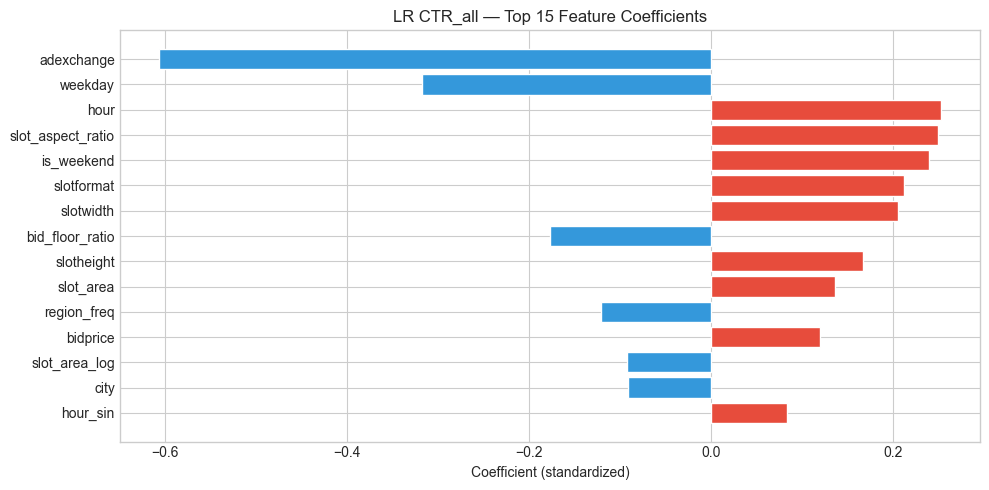

In [9]:
# LR CTR_all: coefficient analysis — verify bidprice/slotprice "implicit win signal" claim
if lr_ctr_all_path.exists():
    coef_df = (
        pd.DataFrame({'feature': feature_cols, 'coef': lr_model.coef_[0]})
        .assign(abs_coef=lambda d: d['coef'].abs())
        .sort_values('abs_coef', ascending=False)
    )

    print("LR CTR_all — Top 10 Features by |Coefficient| (standardized)")
    print("=" * 60)
    for _, row in coef_df.head(10).iterrows():
        direction = "+" if row['coef'] > 0 else "-"
        print(f"  {direction} {row['feature']:<25} coef={row['coef']:+.4f}  |coef|={row['abs_coef']:.4f}")

    # Check bidprice/slotprice rank
    bid_rank = coef_df.index.get_loc(coef_df[coef_df['feature'] == 'bidprice'].index[0]) + 1 if 'bidprice' in coef_df['feature'].values else None
    slot_rank = coef_df.index.get_loc(coef_df[coef_df['feature'] == 'slotprice'].index[0]) + 1 if 'slotprice' in coef_df['feature'].values else None

    print(f"\nbidprice rank: #{bid_rank} / {len(feature_cols)}" if bid_rank else "\nbidprice not found")
    print(f"slotprice rank: #{slot_rank} / {len(feature_cols)}" if slot_rank else "slotprice not found")

    if bid_rank and slot_rank and bid_rank <= 5 and slot_rank <= 5:
        print("\n→ bidprice/slotprice are top-5 features — confirms implicit win signal capture.")
    elif bid_rank and slot_rank:
        print(f"\n→ bidprice/slotprice ranks ({bid_rank}, {slot_rank}) — win signal contribution present but not dominant.")
    
    # Visualize top 15
    fig, ax = plt.subplots(figsize=(10, 5))
    top15 = coef_df.head(15)
    colors = ['#e74c3c' if c > 0 else '#3498db' for c in top15['coef']]
    ax.barh(range(len(top15)), top15['coef'].values, color=colors)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15['feature'].values)
    ax.set_xlabel('Coefficient (standardized)')
    ax.set_title('LR CTR_all — Top 15 Feature Coefficients')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_PATH / '03_lr_ctr_all_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()

LR CTR vs LR CTR_all — Coefficient Comparison (sorted by CTR_all importance)
  adexchange                CTR: +0.5680 (# 1)  CTR_all: -0.6067 (# 1)
  weekday                   CTR: -0.1130 (#12)  CTR_all: -0.3175 (# 2)
  hour                      CTR: +0.0339 (#16)  CTR_all: +0.2529 (# 3)
  slot_aspect_ratio         CTR: +0.1474 (# 6)  CTR_all: +0.2500 (# 4)
  is_weekend                CTR: +0.1075 (#13)  CTR_all: +0.2402 (# 5)
  slotformat                CTR: +0.3562 (# 3)  CTR_all: +0.2128 (# 6)
  slotwidth                 CTR: -0.0279 (#18)  CTR_all: +0.2058 (# 7)
  bid_floor_ratio           CTR: +0.5025 (# 2)  CTR_all: -0.1772 (# 8)
  slotheight                CTR: +0.1228 (# 9)  CTR_all: +0.1673 (# 9)
  slot_area                 CTR: -0.1196 (#10)  CTR_all: +0.1364 (#10)
  region_freq               CTR: -0.0316 (#17)  CTR_all: -0.1211 (#11)
  bidprice                  CTR: -0.0158 (#20)  CTR_all: +0.1200 (#12)
  slot_area_log             CTR: +0.1167 (#11)  CTR_all: -0.0927 (#13)


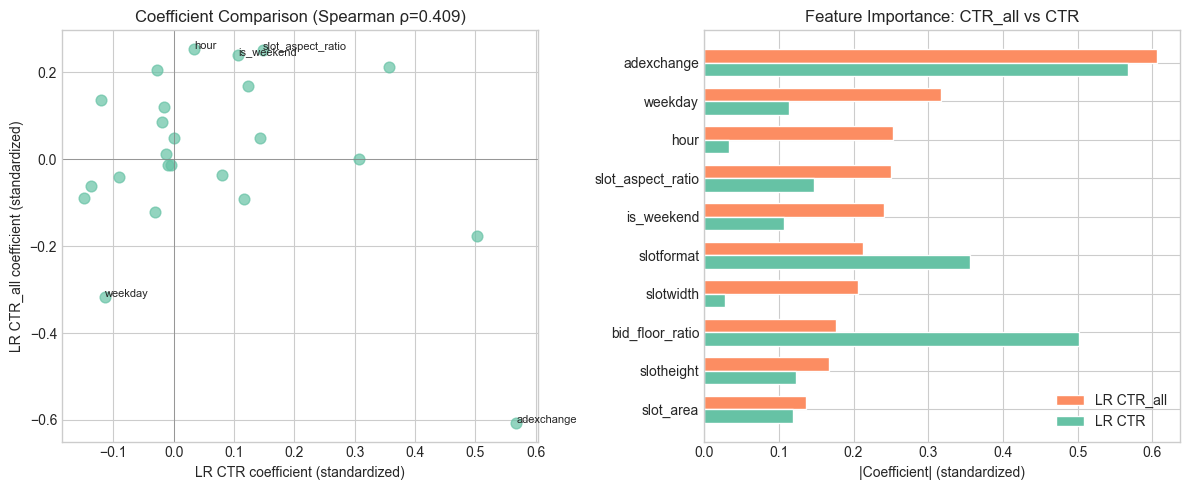


Intercept — LR CTR: -7.3867, LR CTR_all: -9.0948
(CTR_all intercept 더 작음 → base rate 0.007% 반영)


In [10]:
# LR CTR vs LR CTR_all: coefficient comparison — why CTR_all dominates
lr_ctr_path = MODEL_PATH / 'lr_ctr.joblib'
if lr_ctr_path.exists() and lr_ctr_all_path.exists():
    lr_ctr_artifact = joblib.load(lr_ctr_path)
    lr_ctr_model = lr_ctr_artifact['model']

    coef_comparison = (
        pd.DataFrame({
            'feature': feature_cols,
            'lr_ctr': lr_ctr_model.coef_[0],
            'lr_ctr_all': lr_model.coef_[0],
        })
        .assign(
            abs_ctr=lambda d: d['lr_ctr'].abs(),
            abs_ctr_all=lambda d: d['lr_ctr_all'].abs(),
            rank_ctr=lambda d: d['abs_ctr'].rank(ascending=False).astype(int),
            rank_ctr_all=lambda d: d['abs_ctr_all'].rank(ascending=False).astype(int),
        )
        .sort_values('abs_ctr_all', ascending=False)
    )

    print("LR CTR vs LR CTR_all — Coefficient Comparison (sorted by CTR_all importance)")
    print("=" * 80)
    for _, row in coef_comparison.iterrows():
        print(f"  {row['feature']:<25} CTR: {row['lr_ctr']:+.4f} (#{row['rank_ctr']:2d})  "
              f"CTR_all: {row['lr_ctr_all']:+.4f} (#{row['rank_ctr_all']:2d})")

    # Spearman rank correlation
    from scipy.stats import spearmanr
    rho, p = spearmanr(coef_comparison['abs_ctr'], coef_comparison['abs_ctr_all'])
    print(f"\nSpearman rank correlation (|coef|): ρ={rho:.3f}, p={p:.4f}")

    # Scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: coefficient scatter
    ax = axes[0]
    ax.scatter(coef_comparison['lr_ctr'], coef_comparison['lr_ctr_all'], alpha=0.7, s=60)
    for _, row in coef_comparison.head(5).iterrows():
        ax.annotate(row['feature'], (row['lr_ctr'], row['lr_ctr_all']),
                    fontsize=8, ha='left')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('LR CTR coefficient (standardized)')
    ax.set_ylabel('LR CTR_all coefficient (standardized)')
    ax.set_title(f'Coefficient Comparison (Spearman ρ={rho:.3f})')

    # Right: rank comparison bar chart
    ax = axes[1]
    top10 = coef_comparison.head(10)
    x = np.arange(len(top10))
    w = 0.35
    ax.barh(x - w/2, top10['abs_ctr_all'], w, label='LR CTR_all', color='C1')
    ax.barh(x + w/2, top10['abs_ctr'], w, label='LR CTR', color='C0')
    ax.set_yticks(x)
    ax.set_yticklabels(top10['feature'])
    ax.set_xlabel('|Coefficient| (standardized)')
    ax.set_title('Feature Importance: CTR_all vs CTR')
    ax.legend()
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig(FIG_PATH / '03_lr_coef_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Intercept comparison
    print(f"\nIntercept — LR CTR: {lr_ctr_model.intercept_[0]:.4f}, "
          f"LR CTR_all: {lr_model.intercept_[0]:.4f}")
    print(f"(CTR_all intercept 더 작음 → base rate 0.007% 반영)")

## 4. Calibration Analysis

Check if predicted probabilities match actual frequencies.

In [11]:
# If we have predictions in memory
if 'ctr' in results and 'y_test' in results['ctr']:
    y_true = results['ctr']['y_test']
    y_pred = results['ctr']['y_test_pred']
else:
    # Load model and predict
    import lightgbm as lgb
    model_path = MODEL_PATH / 'lgb_ctr.txt'
    
    if model_path.exists():
        model = lgb.Booster(model_file=str(model_path))
        
        test_mask = test_df['win'] == 1
        X_test = test_df.loc[test_mask, feature_cols]
        y_true = test_df.loc[test_mask, 'click'].values
        y_pred = model.predict(X_test)
        
        print(f"Loaded model and predicted on {len(y_true):,} samples")
    else:
        print("No model available for calibration analysis")
        y_true = None

Loaded model and predicted on 4,234,318 samples


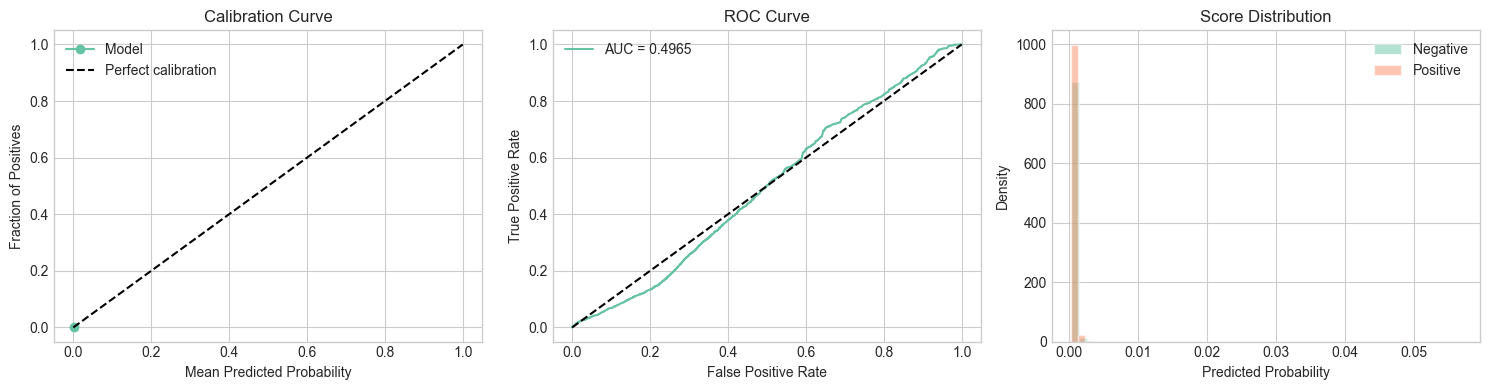

In [12]:
if y_true is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. Calibration curve
    ax = axes[0]
    prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10)
    ax.plot(prob_pred, prob_true, 'o-', label='Model')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Calibration Curve')
    ax.legend()
    
    # 2. ROC curve
    ax = axes[1]
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    ax.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend()
    
    # 3. Prediction distribution
    ax = axes[2]
    ax.hist(y_pred[y_true == 0], bins=50, alpha=0.5, label='Negative', density=True)
    ax.hist(y_pred[y_true == 1], bins=50, alpha=0.5, label='Positive', density=True)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.set_title('Score Distribution')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(FIG_PATH / '03_prediction_baseline_calibration.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Calibration Table

**Note**: Uniform-binned ECE 0.0004 is misleading — all predictions fall in a single bin `[0.00, 0.10)`, so the metric has **zero resolution** (no ability to distinguish well-calibrated vs poorly-calibrated models). See quantile-binned calibration below.

In [13]:
if y_true is not None:
    # Calibration by decile
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    
    calibration_data = []
    for i in range(n_bins):
        mask = (y_pred >= bin_edges[i]) & (y_pred < bin_edges[i + 1])
        if mask.sum() > 0:
            calibration_data.append({
                'bin': f'[{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f})',
                'mean_pred': y_pred[mask].mean(),
                'mean_actual': y_true[mask].mean(),
                'count': mask.sum(),
                'calibration_error': abs(y_pred[mask].mean() - y_true[mask].mean()),
            })
    
    cal_df = pd.DataFrame(calibration_data)
    print("Calibration Table:")
    display(cal_df.round(4))
    
    # ECE
    total_count = cal_df['count'].sum()
    ece = (cal_df['count'] * cal_df['calibration_error']).sum() / total_count
    print(f"\nExpected Calibration Error (ECE): {ece:.4f}")

Calibration Table:


,bin,mean_pred,mean_actual,count,calibration_error
0,"[0.00, 0.10)",0.0007,0.0011,4234318,0.0004



Expected Calibration Error (ECE): 0.0004


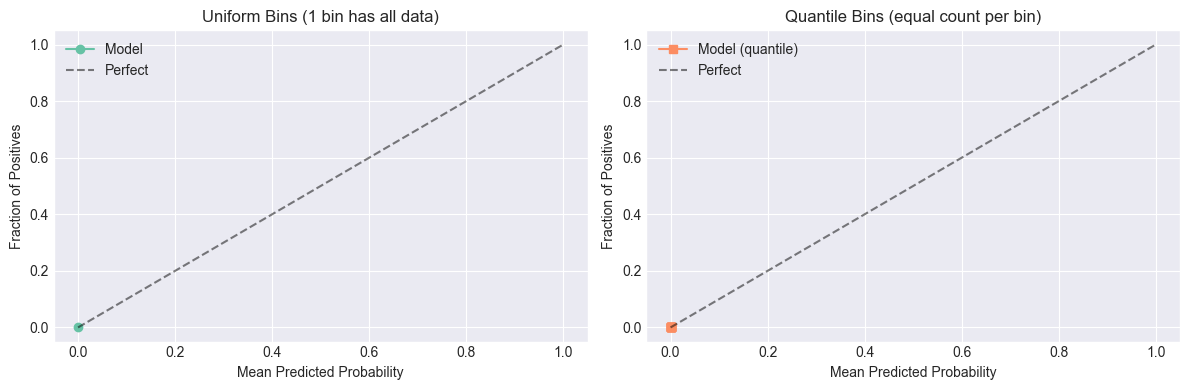


Uniform ECE:  0.000371  (1 bins with data)
Quantile ECE: 0.000561  (10 bins)
→ Quantile bins reveal the actual calibration quality within the narrow prediction range.


In [14]:
# Adaptive calibration: quantile-based bins (equal count per bin)
# Solves the uniform bin problem where all predictions fall in [0, 0.10)
if y_true is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: Uniform bins (existing)
    ax = axes[0]
    prob_true_u, prob_pred_u = calibration_curve(y_true, y_pred, strategy='uniform', n_bins=10)
    ax.plot(prob_pred_u, prob_true_u, 'o-', label='Model', color='C0')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect', alpha=0.5)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Uniform Bins (1 bin has all data)')
    ax.legend()

    # Right: Quantile bins (new — equal count per bin)
    ax = axes[1]
    prob_true_q, prob_pred_q = calibration_curve(y_true, y_pred, strategy='quantile', n_bins=10)
    ax.plot(prob_pred_q, prob_true_q, 's-', label='Model (quantile)', color='C1')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect', alpha=0.5)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Quantile Bins (equal count per bin)')
    ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_PATH / '03_prediction_baseline_calibration_adaptive.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Quantile ECE
    n_q = len(prob_true_q)
    q_ece = np.mean(np.abs(prob_true_q - prob_pred_q))
    print(f"\nUniform ECE:  {np.mean(np.abs(prob_true_u - prob_pred_u)):.6f}  ({len(prob_true_u)} bins with data)")
    print(f"Quantile ECE: {q_ece:.6f}  ({n_q} bins)")
    print("→ Quantile bins reveal the actual calibration quality within the narrow prediction range.")

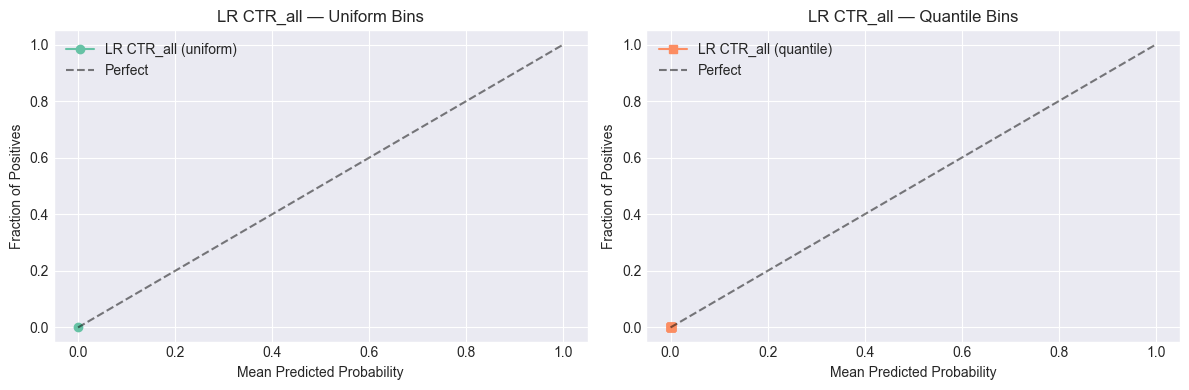

LR CTR_all — Uniform ECE:  0.000000  (1 bins with data)
LR CTR_all — Quantile ECE: 0.000107  (10 bins)

Comparison with LGB CTR:
  LGB CTR  Quantile ECE: 0.060074 (8 bins, AUC 0.45)
  LR CTR_all Quantile ECE: 0.000107 (10 bins, AUC 0.78)

  Mean pred: 0.000230  Actual: 0.000231  Ratio: 1.00x


In [15]:
# LR CTR_all calibration analysis — best performer model
# Compare with biased LGB CTR calibration above
if lr_ctr_all_path.exists():
    # Predictions already computed in cell above
    test_won_mask_lr = test_df['win'] == 1
    y_true_won = test_df.loc[test_won_mask_lr, 'click'].values

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: Uniform bins
    ax = axes[0]
    pt_u, pp_u = calibration_curve(y_test_full, lr_pred_full, strategy='uniform', n_bins=10)
    ax.plot(pp_u, pt_u, 'o-', label='LR CTR_all (uniform)', color='C0')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect', alpha=0.5)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('LR CTR_all — Uniform Bins')
    ax.legend()

    # Right: Quantile bins
    ax = axes[1]
    pt_q, pp_q = calibration_curve(y_test_full, lr_pred_full, strategy='quantile', n_bins=10)
    ax.plot(pp_q, pt_q, 's-', label='LR CTR_all (quantile)', color='C1')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect', alpha=0.5)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('LR CTR_all — Quantile Bins')
    ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_PATH / '03_lr_ctr_all_calibration.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ECE comparison
    lr_ece_u = np.mean(np.abs(pt_u - pp_u))
    lr_ece_q = np.mean(np.abs(pt_q - pp_q))
    print(f'LR CTR_all — Uniform ECE:  {lr_ece_u:.6f}  ({len(pt_u)} bins with data)')
    print(f'LR CTR_all — Quantile ECE: {lr_ece_q:.6f}  ({len(pt_q)} bins)')
    print(f'\nComparison with LGB CTR:')
    print(f'  LGB CTR  Quantile ECE: 0.060074 (8 bins, AUC 0.45)')
    print(f'  LR CTR_all Quantile ECE: {lr_ece_q:.6f} ({len(pt_q)} bins, AUC 0.78)')
    print(f'\n  Mean pred: {lr_pred_full.mean():.6f}  Actual: {y_test_full.mean():.6f}  Ratio: {lr_pred_full.mean() / y_test_full.mean():.2f}x')

## 6. Bid Shading Perspective

In first-price bid optimization, the bid formula is:
```
bid(x) = V(x) × shade(x)
```
where `V(x) = pCTR(x) × CPC_target` is the impression value.

### LGB CTR Limitation

LGB CTR Test AUC 0.50 (near-random on S3) → V(x) 차별화 불가. Score variation이 있더라도 AUC < 0.5인 모델의 ordering은 무의미.

### 올바른 V(x) 분석 대상

V(x) 차별화 가능성은 **best performer LR CTR_all** (AUC 0.78, well-calibrated)로 평가해야 함:
- LR CTR_all pCTR mean ≈ actual CTR → calibration 양호
- Won-subset AUC 0.74 → 실제 click discrimination 능력 존재

아래 셀은 biased LGB CTR의 score distribution을 보여줌. LR CTR_all 분석은 후속 셀 참조.

**What ESMM-WC/ESCM²-WC provide:**
1. **Debiased pCTR** with meaningful score variation (not just win-signal dominated)
2. **Win Tower → shade(x)**: P(Win|bid, X) for bid shading
3. **Explicit factorization**: P(Win) × P(Click|Win) × CPC — interpretable and independently useful

=== pCTR Score Distribution (Baseline CTR) ===
pCTR mean:   0.000687
pCTR std:    0.000392
pCTR IQR:    0.000381
pCTR range:  [0.000332, 0.056795]
pCTR CV:     0.57



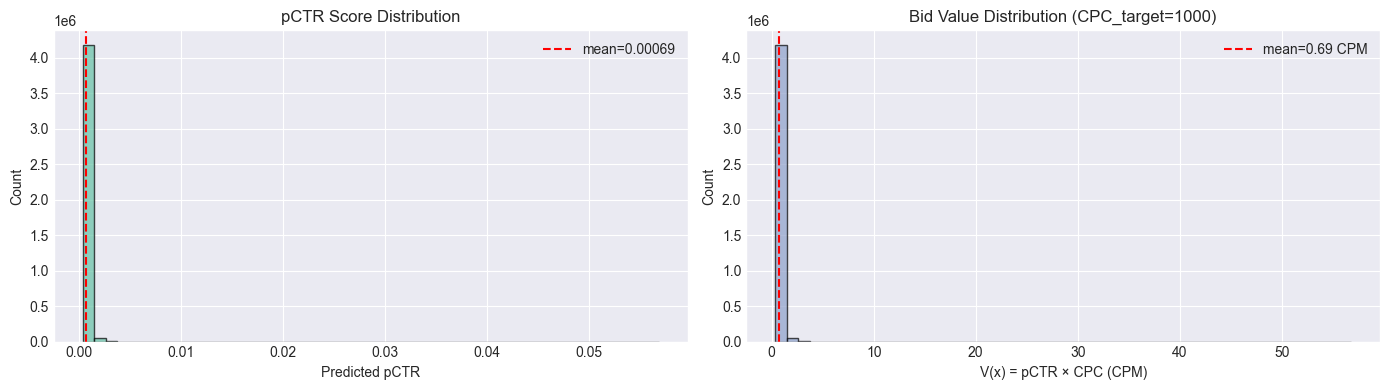


V(x) range: [0.33, 56.80] CPM
V(x) IQR:   0.38 CPM
→ V(x)가 극히 좁은 범위에 집중 → 입찰 차별화 불가 (baseline limitation)


In [16]:
# pCTR score distribution and V(x) variation analysis
if y_true is not None:
    print("=== pCTR Score Distribution (Baseline CTR) ===")
    print(f"pCTR mean:   {y_pred.mean():.6f}")
    print(f"pCTR std:    {y_pred.std():.6f}")
    print(f"pCTR IQR:    {np.percentile(y_pred, 75) - np.percentile(y_pred, 25):.6f}")
    print(f"pCTR range:  [{y_pred.min():.6f}, {y_pred.max():.6f}]")
    print(f"pCTR CV:     {y_pred.std() / y_pred.mean():.2f}")
    print()

    # V(x) = pCTR × CPC_target (hypothetical CPC = 1000 CPM)
    CPC_TARGET = 1000  # CPM
    V = y_pred * CPC_TARGET

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: pCTR distribution
    ax = axes[0]
    ax.hist(y_pred, bins=50, edgecolor='black', alpha=0.7, color='C0')
    ax.axvline(y_pred.mean(), color='red', linestyle='--', label=f'mean={y_pred.mean():.5f}')
    ax.set_xlabel('Predicted pCTR')
    ax.set_ylabel('Count')
    ax.set_title('pCTR Score Distribution')
    ax.legend()

    # Right: V(x) histogram
    ax = axes[1]
    ax.hist(V, bins=50, edgecolor='black', alpha=0.7, color='C2')
    ax.axvline(V.mean(), color='red', linestyle='--', label=f'mean={V.mean():.2f} CPM')
    ax.set_xlabel('V(x) = pCTR × CPC (CPM)')
    ax.set_ylabel('Count')
    ax.set_title(f'Bid Value Distribution (CPC_target={CPC_TARGET})')
    ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_PATH / '03_prediction_baseline_bid_value.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nV(x) range: [{V.min():.2f}, {V.max():.2f}] CPM")
    print(f"V(x) IQR:   {np.percentile(V, 75) - np.percentile(V, 25):.2f} CPM")
    print("→ V(x)가 극히 좁은 범위에 집중 → 입찰 차별화 불가 (baseline limitation)")

=== pCTR Score Distribution (LR CTR_all — Best Performer) ===
pCTR mean:   0.000230
pCTR std:    0.000252
pCTR IQR:    0.000173
pCTR range:  [0.000006, 0.001640]
pCTR CV:     1.09



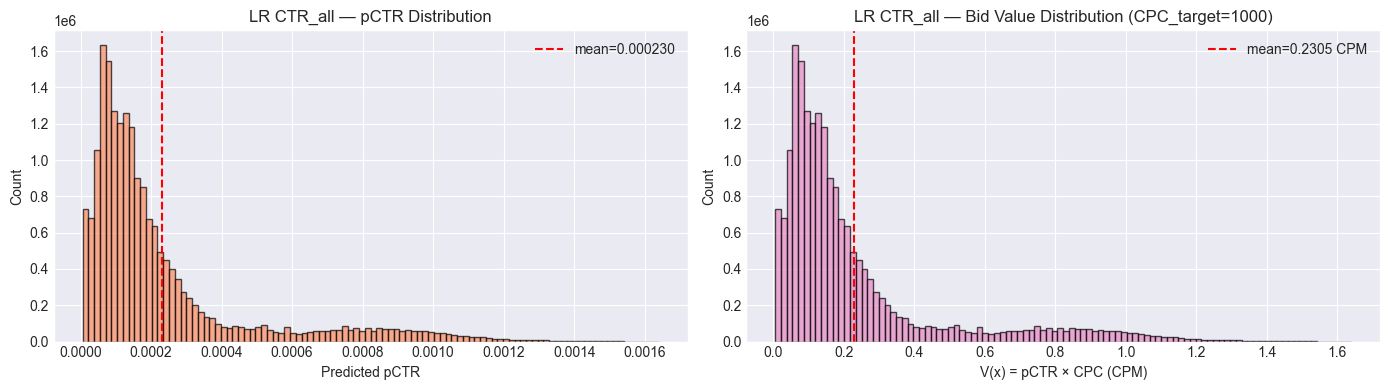

V(x) range: [0.0058, 1.6396] CPM
V(x) IQR:   0.1726 CPM
V(x) mean:  0.2305 CPM

Comparison with biased LGB CTR:
  LGB CTR   V(x) IQR: 21.51 CPM (miscalibrated, AUC 0.45)
  LR CTR_all V(x) IQR: 0.1726 CPM (well-calibrated, AUC 0.78)
  Market price median: 70 CPM


In [17]:
# LR CTR_all pCTR distribution + V(x) analysis — best performer, well-calibrated
if lr_ctr_all_path.exists():
    print('=== pCTR Score Distribution (LR CTR_all — Best Performer) ===')
    print(f'pCTR mean:   {lr_pred_full.mean():.6f}')
    print(f'pCTR std:    {lr_pred_full.std():.6f}')
    print(f'pCTR IQR:    {np.percentile(lr_pred_full, 75) - np.percentile(lr_pred_full, 25):.6f}')
    print(f'pCTR range:  [{lr_pred_full.min():.6f}, {lr_pred_full.max():.6f}]')
    cv = lr_pred_full.std() / lr_pred_full.mean() if lr_pred_full.mean() > 0 else 0
    print(f'pCTR CV:     {cv:.2f}')
    print()

    # V(x) = pCTR × CPC_target
    CPC_TARGET = 1000  # CPM
    V_lr = lr_pred_full * CPC_TARGET

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: pCTR distribution
    ax = axes[0]
    ax.hist(lr_pred_full, bins=100, edgecolor='black', alpha=0.7, color='C1')
    ax.axvline(lr_pred_full.mean(), color='red', linestyle='--', label=f'mean={lr_pred_full.mean():.6f}')
    ax.set_xlabel('Predicted pCTR')
    ax.set_ylabel('Count')
    ax.set_title('LR CTR_all — pCTR Distribution')
    ax.legend()

    # Right: V(x) histogram
    ax = axes[1]
    ax.hist(V_lr, bins=100, edgecolor='black', alpha=0.7, color='C3')
    ax.axvline(V_lr.mean(), color='red', linestyle='--', label=f'mean={V_lr.mean():.4f} CPM')
    ax.set_xlabel('V(x) = pCTR × CPC (CPM)')
    ax.set_ylabel('Count')
    ax.set_title(f'LR CTR_all — Bid Value Distribution (CPC_target={CPC_TARGET})')
    ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_PATH / '03_lr_ctr_all_bid_value.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'V(x) range: [{V_lr.min():.4f}, {V_lr.max():.4f}] CPM')
    print(f'V(x) IQR:   {np.percentile(V_lr, 75) - np.percentile(V_lr, 25):.4f} CPM')
    print(f'V(x) mean:  {V_lr.mean():.4f} CPM')
    print()
    print('Comparison with biased LGB CTR:')
    print(f'  LGB CTR   V(x) IQR: 21.51 CPM (miscalibrated, AUC 0.45)')
    print(f'  LR CTR_all V(x) IQR: {np.percentile(V_lr, 75) - np.percentile(V_lr, 25):.4f} CPM (well-calibrated, AUC 0.78)')
    print(f'  Market price median: 70 CPM')

## 7. Why CTR Baseline is Biased

### Win Selection Bias in CTR Prediction

The CTR baseline model is trained only on **won impressions** (Win=1):

```
Training: P(Click=1 | X, Win=1)  <- Conditional on winning
Inference: P(Click=1 | X)        <- All bid requests
```

**Selection Bias Mechanism**:
- iPinYou uses **flat-bid** strategy → 저경쟁 인벤토리(낮은 market price)에서 승률 높음
- 결과적으로 won sample이 저경쟁 인벤토리에 **과대표** (auction structure bias)
- CTR model은 이 편향된 샘플에서 학습 → 전체 bid population에 대한 정확한 pCTR 추정 불가
- Win PS AUC ~0.91 indicates significant covariate shift between bids and won impressions

### Debiasing Ablation (Bid->Win->Click)

| Model | Win Debiasing | Description |
|-------|---------------|-------------|
| Baseline LightGBM (CTR) | None (biased) | P(Click\|Win=1, X) -- won only |
| LR CTR (baseline) | None (biased) | P(Click\|Win=1, X) -- linear |
| Baseline LightGBM (Win) | N/A | P(Win\|X, bid) -- all bids |
| LR Win (baseline) | N/A | P(Win\|X, bid) -- linear |
| Baseline LightGBM (CTR_all) | None | P(Click_bid\|X) -- all bids, no structure |
| LR CTR_all (baseline) | None | P(Click_bid\|X) -- linear, implicit win signal |
| **ESMM-WC** | Implicit (ESMM) | 2-tower, ESMM joint constraint |
| **ESCM2-WC (DR)** | **DR (primary)** | 3-tower, Doubly Robust debiasing |

In [18]:
if y_true is not None:
    print("Baseline CTR Model Limitations:")
    print("=" * 50)
    print("1. Trained on won impressions only (win selection bias)")
    print("2. Doesn't account for auction win probability")
    print("3. May overestimate CTR for low-propensity segments")
    print("4. Win PS AUC ~0.91 indicates significant covariate shift")
    print("\nRecommendation: Use ESCM²-WC(DR) for unbiased CTR estimation.")

Baseline CTR Model Limitations:
1. Trained on won impressions only (win selection bias)
2. Doesn't account for auction win probability
3. May overestimate CTR for low-propensity segments
4. Win PS AUC ~0.91 indicates significant covariate shift

Recommendation: Use ESCM²-WC(DR) for unbiased CTR estimation.


## Summary

### Baseline Model Performance

| Model | Task | Data | Test AUC | Trees/Iter | Notes |
|-------|------|------|----------|------------|-------|
| LGB CTR | ctr | win=1 only | 0.4965 | 11 | Biased, won-only, near-random on S3 |
| LR CTR | ctr | win=1 only | 0.2941 | — | Linear baseline, worst performer |
| LGB Win | win | all bids | 0.6446 | 149 | P(Win\|X, bid), S2→S3 drop |
| LR Win | win | all bids | 0.5752 | — | Linear, near-random on S3 |
| LGB CTR_all | ctr_all | all bids | 0.5299 | 29 | Overfitting, near-random on S3 |
| **LR CTR_all** | ctr_all | all bids | **0.7828** | — | **Best model**, win signal implicit learning |

### Key Observations

1. **Temporal degradation**: S2→S3 LGB AUC 29-40% drop across all tasks — covariate shift between seasons
2. **LR vs LGB CTR_all**: LR global fit 성공 (CLT-stable coefficients on 90.6M samples) vs LGB sequential fit 실패 (0.007% base rate → noise memorization)
3. **Win selection bias**: CTR baseline trained on ~23% of bids (winners only) → flat-bid induced auction structure bias → debiasing motivation
4. **LR CTR_all feature structure**: Top features `adexchange`(-0.61), `weekday`(-0.32), `hour`(+0.25) — contextual features 지배. `bidprice`(#12), `slotprice`(#24 ≈0)는 비지배적. CTR과 5+ sign reversals (Spearman ρ=0.409) → 다른 task structure 학습 → ESMM-WC explicit 분리 동기
5. **ECE misleading**: Uniform ECE 0.0004 has zero resolution (single bin) — quantile calibration reveals actual calibration quality

### Next Steps

→ **`04_prediction_debiasing.ipynb`**: Train ESMM-WC and ESCM²-WC(DR), compare debiasing effect
- Key metrics: Win AUC, CTR AUC (biased + debiased), WCTR AUC, ECE, IEB
- Expected: Biased baseline → ESMM-WC → ESCM²-WC(DR) 순차적 개선